In [1]:
# import libraries, configure charts, and create output folders
import os
import tempfile
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ai_productivity_matplotlib"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# keep every generated file inside this project folder
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data"
IMAGES_DIR = PROJECT_DIR / "images"
RESULTS_DIR = PROJECT_DIR / "results"
IMAGES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# format for basic plots
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("muted")

print("Project folder:", PROJECT_DIR)
print("Data folder:", DATA_DIR)
print("Images folder:", IMAGES_DIR)
print("Results folder:", RESULTS_DIR)


Project folder: /Users/chen/Desktop/ai-productivity-analysis-811141-main
Images folder: /Users/chen/Desktop/ai-productivity-analysis-811141-main/images
Results folder: /Users/chen/Desktop/ai-productivity-analysis-811141-main/results


### Load the Dataset

This cell loads the CSV that we are working on. The expected output is the dataset shape and the first five rows. This confirms that the file is available and that columns are present, e.g. `ai_usage_pct`, `hours_spent`, `rework_hours`, `outcome_score`, `revenue`, `cost`, `profit`, `pricing_model`, `seniority`, and `task_type`.


In [2]:
# Load data from the project data folder
df = pd.read_csv(DATA_DIR / "ai_productivity_dataset_final.csv")

# shape and the head of the df so we know the file loaded correctly
print("Shape:", df.shape)
display(df.head())


Shape: (3248, 34)


,task_id,client,project_id,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,...,revenue,cost,profit,created_by,updated_at,task_status,workflow_stage,jira_ticket,legacy_ai_flag,content_version
0,T00000,Client_F,P038,mid,Content,report,junior,2,3.0,high,...,498.11,346.17,151.94,user_096,11/28/2025,review,finalized,JIRA-49014,TRUE,v1
1,T00001,Client_H,P028,low,Paid Media,release,junior,1,2.0,medium,...,847.01,343.18,503.83,user_058,1/26/2026,delivered,client_review,JIRA-84793,FALSE,v1
2,T00002,Client_D,P009,low,Design,dev,junior,3,4.0,medium,...,1374.07,365.02,1009.05,user_074,9/17/2025,in_progress,qa,JIRA-42485,TRUE,v2
3,T00003,Client_E,P023,mid,Content,design,mid,3,2.0,low,...,2379.11,1514.73,864.38,user_011,11/12/2025,in_progress,briefing,JIRA-53111,FALSE,v1
4,T00004,Client_C,P014,low,Design,article,senior,2,5.0,low,...,709.95,335.27,374.68,user_007,5/9/2026,review,execution,JIRA-86006,TRUE,v2


## Clean the Data

The raw data has inconsistent labels, date columns stored as text, duplicated task IDs, and typo variants such as `DEV`, `dev_task`, and `development`. This cell cleans those issues. The duplicate rule is made in a following way. When the same `task_id` appears more than once, we keep the latest `updated_at` version values.

The output is a data-quality audit and the cleaned row count, so the reader understands exactly what changed before analysis begins.


In [3]:
# Parse dates, fix labels, remove duplicate task versions, and making an audit of data quality
data = df.copy()

# Convert date columns from strings into real datetime objects
for col in ["created_at", "delivered_at", "updated_at"]:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], errors="coerce")

# Standardise text columns by removing spaces and making everything lowercase
for col in ["task_type", "team", "pricing_model", "seniority", "client_tier",
            "deadline_pressure", "task_status", "workflow_stage"]:
    data[col] = data[col].astype(str).str.strip().str.lower()

# Map dirty task-types into clean categories
task_map = {
    "dev_task": "dev", "development": "dev", "dev": "dev",
    "design_task": "design", "design": "design",
    "report_task": "report", "report": "report", "repport": "report",
    "release_task": "release", "release": "release", "relese": "release",
    "article_task": "article", "article": "article", "artcle": "article", "blog_article": "article",
    "ad_task": "ad", "ad": "ad", "paid_ad": "ad", "creative": "ad",
    "ticket_task": "ticket", "ticket": "ticket", "support_ticket": "ticket",
}
data["task_type"] = data["task_type"].replace(task_map)

# Same idea for teams: fix typo variants and standardise labels.
data["team"] = data["team"].replace({
    "contennt": "content",
    "paid media": "media",
    "desgn": "design",
})

# Convert numeric columns explicitly so later math is safe
numeric_cols = [
    "task_complexity_score", "brief_quality_score", "sla_days",
    "hours_spent", "billable_hours", "ai_usage_pct", "revisions",
    "errors", "rework_hours", "outcome_score", "revenue", "cost", "profit",
]
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# keep the latest updated row for every task_id because there are duplicates
# Status/stage priority is used only as a tie-breaker when updated_at is equal
status_priority = {"archived": 0, "blocked": 1, "draft": 2, "in_progress": 3, "review": 4, "delivered": 5}
stage_priority = {"briefing": 1, "execution": 2, "qa": 3, "client_review": 4, "finalized": 5}
data["_status_priority"] = data["task_status"].map(status_priority).fillna(-1)
data["_stage_priority"] = data["workflow_stage"].map(stage_priority).fillna(-1)

raw_rows = len(data)
raw_unique_tasks = data["task_id"].nunique()
data = (
    data.sort_values(["task_id", "updated_at", "_status_priority", "_stage_priority"])
        .drop_duplicates("task_id", keep="last")
        .drop(columns=["_status_priority", "_stage_priority"])
        .copy()
)

# Summarise the main data-quality checks
audit = pd.DataFrame([
    ("raw rows", raw_rows, "rows before cleaning"),
    ("unique task_id", raw_unique_tasks, "unique task identifiers in raw data"),
    ("duplicate extra rows removed", raw_rows - raw_unique_tasks, "removed by keeping latest task version"),
    ("clean rows", len(data), "rows after cleaning"),
    ("missing ai_usage_pct", data["ai_usage_pct"].isna().sum(), "excluded from AI-band analysis"),
    ("negative billable_hours", (data["billable_hours"] < 0).sum(), "data-quality issue to remember"),
    ("rework_hours > hours_spent", (data["rework_hours"] > data["hours_spent"]).sum(), "possible rework-ratio outliers"),
], columns=["check", "count", "meaning"])

display(audit)
print("Cleaned task types:", sorted(data["task_type"].unique()))
print("Cleaned teams:", sorted(data["team"].unique()))


,check,count,meaning
0,raw rows,3248,rows before cleaning
1,unique task_id,3200,unique task identifiers in raw data
2,duplicate extra rows removed,48,removed by keeping latest task version
3,clean rows,3200,rows after cleaning
4,missing ai_usage_pct,143,excluded from AI-band analysis
5,negative billable_hours,17,data-quality issue to remember
6,rework_hours > hours_spent,67,possible rework-ratio outliers


Cleaned task types: ['ad', 'article', 'design', 'dev', 'release', 'report', 'ticket']
Cleaned teams: ['content', 'design', 'media', 'seo']


### Engineer the Business Metrics

We create our comparable metrics. Which are:
- `margin_pct`: profit as a share of revenue
- `rework_ratio`: correction time as a share of total time
- `is_loss`: whether the task lost money
- `ai_band`: five 20-point AI usage groups

The output shows how many rows can be used for AI analysis and describes the new metrics.

In [4]:
# Keep only rows with AI usage and create metrics for the analysis
data_clean = data[data["ai_usage_pct"].notna()].copy()
print("Rows with AI usage data:", len(data_clean))

# Margin percentage tells us how much of revenue becomes profit
data_clean["margin_pct"] = data_clean["profit"] / data_clean["revenue"].replace(0, np.nan)

# Rework ratio tells us how much task time was spent fixing or revising work
data_clean["rework_ratio"] = data_clean["rework_hours"] / data_clean["hours_spent"].replace(0, np.nan)

# Cap extreme margin values for robustness checks. The original margin is still kept for the main business interpretation.
margin_low = data_clean["margin_pct"].quantile(0.01)
margin_high = data_clean["margin_pct"].quantile(0.99)
data_clean["margin_pct_capped"] = data_clean["margin_pct"].clip(lower=margin_low, upper=margin_high)

# Cap extreme rework ratios at the 99th percentile so a few almost zero hour tasks do not distort the averages
rework_cap = data_clean["rework_ratio"].quantile(0.99)
data_clean["rework_ratio_capped"] = data_clean["rework_ratio"].clip(upper=rework_cap)

# True and False values of the loss flag can be averaged later to calculate a loss rate
data_clean["is_loss"] = data_clean["profit"] < 0

# AI usage bands make the continuous ai_usage_pct column easier to compare.
ORDER = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]
data_clean["ai_band"] = pd.cut(
    data_clean["ai_usage_pct"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=ORDER,
    include_lowest=True,
)
data_clean["ai_band"] = pd.Categorical(data_clean["ai_band"], categories=ORDER, ordered=True)

display(
    data_clean[["ai_usage_pct", "margin_pct", "margin_pct_capped", "rework_ratio_capped"]]
    .describe()
    .T
    .round(3)
)


Rows with AI usage data: 3057


,count,mean,std,min,25%,50%,75%,max
ai_usage_pct,3057.0,0.362,0.199,0.000,0.200,0.340,0.500,0.930
margin_pct,3057.0,0.151,0.767,-16.737,0.002,0.293,0.514,0.963
margin_pct_capped,3057.0,0.173,0.553,-2.666,0.002,0.293,0.514,0.870
rework_ratio_capped,2991.0,0.236,0.261,0.000,0.091,0.165,0.291,1.788


### Robustness Check: Outliers and Small Groups

The raw margin percentage contains a few extreme negative values, so the notebook keeps the original margin for interpretation and also creates a capped version for robustness. This cell checks whether the main story survives when outliers are capped and flags AI bands with small sample sizes.


In [5]:
# Compare original and capped margin to test whether outliers drive the conclusion
robustness = (
    data_clean.groupby("ai_band", observed=False)
    .agg(
        n=("task_id", "count"),
        avg_margin=("margin_pct", "mean"),
        median_margin=("margin_pct", "median"),
        avg_margin_capped=("margin_pct_capped", "mean"),
        min_margin=("margin_pct", "min"),
        max_margin=("margin_pct", "max"),
    )
    .reset_index()
)
robustness["small_sample_flag"] = robustness["n"] < 50
robustness.to_csv(RESULTS_DIR / "robustness_summary.csv", index=False)

print(f"Margin cap used for robustness: {margin_low:.2f} to {margin_high:.2f}")
display(robustness.round(3))


Margin cap used for robustness: -2.67 to 0.87


,ai_band,n,avg_margin,median_margin,avg_margin_capped,min_margin,max_margin,small_sample_flag
0,0-20%,778,0.060,0.210,0.082,-10.319,0.946,False
1,20-40%,1069,0.103,0.270,0.139,-16.737,0.952,False
2,40-60%,812,0.246,0.353,0.250,-5.595,0.962,False
3,60-80%,350,0.265,0.393,0.287,-9.662,0.963,False
4,80-100%,48,0.288,0.490,0.303,-3.385,0.934,True


### Summarise AI Usage Bands

This cell creates the main summary table. The output shows the number of tasks in each AI band and the average values for hours, rework, quality, profit, margin, and loss rate. This is the table behind most figures and the README results.


In [6]:
# Build a summary table. One row per AI band with average key metrics
summary = (
    data_clean.groupby("ai_band", observed=False)
    .agg(
        n_tasks     = ("task_id",             "count"),
        avg_hours   = ("hours_spent",          "mean"),
        avg_rework  = ("rework_ratio_capped",  "mean"),
        avg_outcome = ("outcome_score",        "mean"),
        avg_profit  = ("profit",               "mean"),
        avg_margin  = ("margin_pct",           "mean"),
        median_margin = ("margin_pct",         "median"),
        avg_margin_capped = ("margin_pct_capped", "mean"),
        loss_rate   = ("is_loss",              "mean"),
    )
    .reset_index()
)

# we keep the AI bands in correct ordering
summary["ai_band"] = pd.Categorical(summary["ai_band"], categories=ORDER, ordered=True)
summary = summary.sort_values("ai_band").reset_index(drop=True)

# Save csv
summary.to_csv(RESULTS_DIR / "ai_band_summary.csv", index=False)

display(summary.round(3))


,ai_band,n_tasks,avg_hours,avg_rework,avg_outcome,avg_profit,avg_margin,median_margin,avg_margin_capped,loss_rate
0,0-20%,778,13.288,0.191,69.018,230.240,0.060,0.210,0.082,0.310
1,20-40%,1069,13.750,0.218,68.734,308.384,0.103,0.270,0.139,0.264
2,40-60%,812,12.668,0.260,69.484,466.145,0.246,0.353,0.250,0.213
3,60-80%,350,10.790,0.322,68.123,458.441,0.265,0.393,0.287,0.163
4,80-100%,48,10.937,0.362,64.388,718.461,0.288,0.490,0.303,0.146


## Generate the Speed and Aggregate Margin Figure

This figure checks the first surface-level question: does more AI usage reduce hours, and does the aggregate margin appear to rise? The left chart should show lower average hours at higher AI usage. The right chart should show that aggregate margin improves, but this is only the first layer because pricing model still needs to be separated.


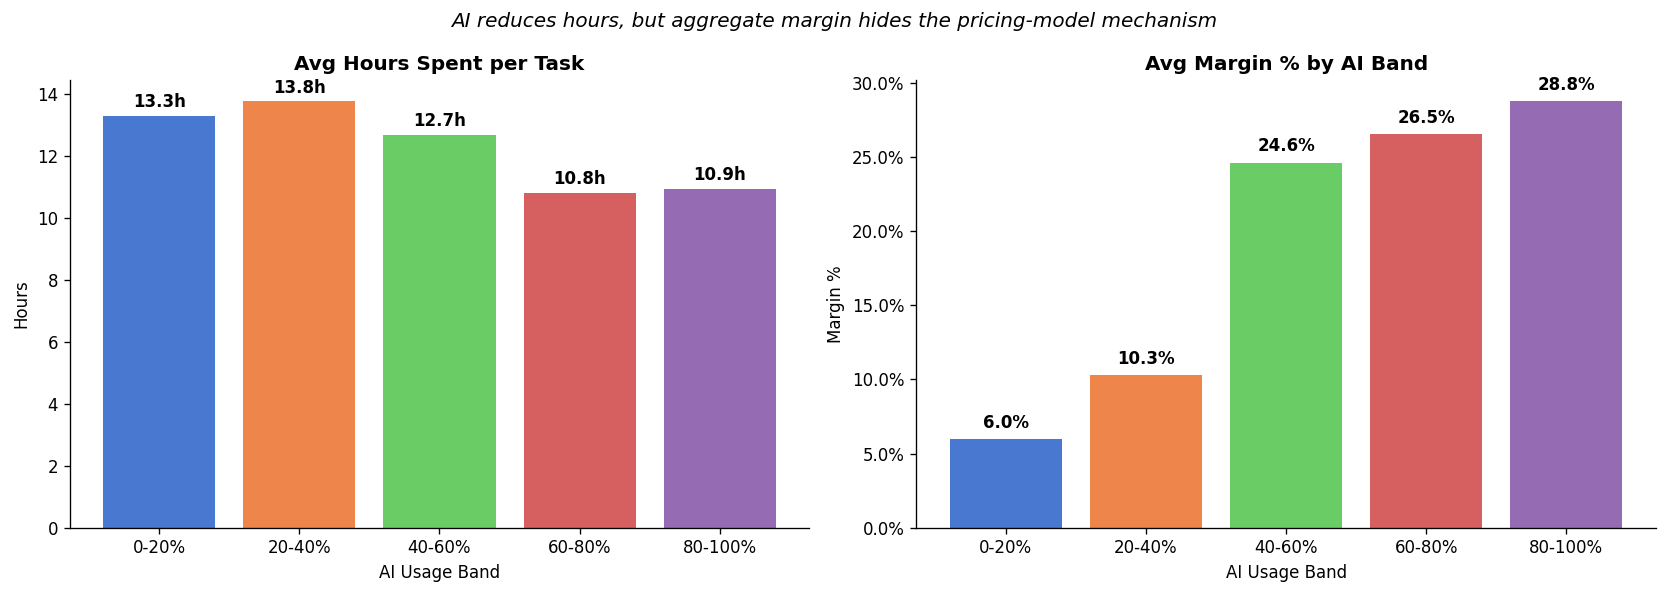

In [7]:
#Compare average hours and average margin across AI usage bands
palette = sns.color_palette("muted", 5)
bands = summary["ai_band"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Left chart: average hours per AI usage band.
ax = axes[0]
bars = ax.bar(bands, summary["avg_hours"], color=palette)
ax.set_title("Avg Hours Spent per Task", fontweight="bold")
ax.set_xlabel("AI Usage Band")
ax.set_ylabel("Hours")
for b, v in zip(bars, summary["avg_hours"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.15,
            f"{v:.1f}h", ha="center", va="bottom", fontsize=10, fontweight="bold")

#Right chart: average margin by AI usage band.
ax = axes[1]
bars = ax.bar(bands, summary["avg_margin"] * 100, color=palette)
ax.set_title("Avg Margin % by AI Band", fontweight="bold")
ax.set_xlabel("AI Usage Band")
ax.set_ylabel("Margin %")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for b, v in zip(bars, summary["avg_margin"] * 100):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
            f"{v:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("AI reduces hours, but aggregate margin hides the pricing-model mechanism",
             fontsize=12, style="italic")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "ai_band_overview.png", bbox_inches="tight")
plt.show()


## Generate the Quality and Rework Figure

Speed is only useful if quality does not collapse. This cell plots outcome score and rework ratio by AI usage band. The expected pattern is that outcome score is strongest around 40-60% AI usage, while rework rises as AI usage increases.


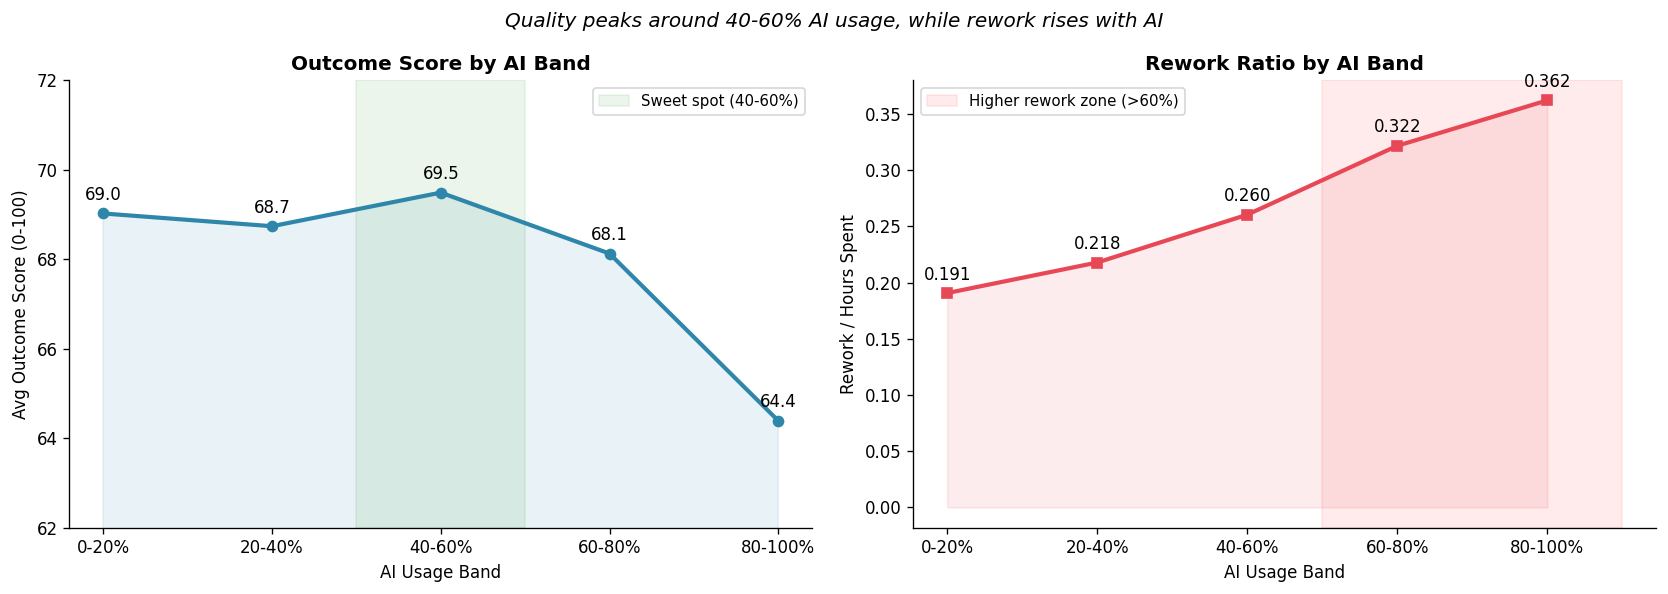

In [8]:
#Track outcome score and rework ratio across AI bands to check whether quality holds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = summary["ai_band"].astype(str)

#Left chart: outcome score by band.
ax = axes[0]
ax.plot(x, summary["avg_outcome"], marker="o", linewidth=2.5, color="#2E86AB")
ax.fill_between(range(len(summary)), summary["avg_outcome"], alpha=0.1, color="#2E86AB")
ax.axvspan(1.5, 2.5, alpha=0.08, color="green", label="Sweet spot (40-60%)")
ax.set_title("Outcome Score by AI Band", fontweight="bold")
ax.set_xlabel("AI Usage Band")
ax.set_ylabel("Avg Outcome Score (0-100)")
ax.set_ylim(62, 72)
ax.legend(fontsize=9)
for i, v in enumerate(summary["avg_outcome"]):
    ax.annotate(f"{v:.1f}", (i, v), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=10)

#Right chart: rework ratio by band.
ax = axes[1]
ax.plot(x, summary["avg_rework"], marker="s", linewidth=2.5, color="#E84855")
ax.fill_between(range(len(summary)), summary["avg_rework"], alpha=0.1, color="#E84855")
ax.axvspan(2.5, 4.5, alpha=0.08, color="red", label="Higher rework zone (>60%)")
ax.set_title("Rework Ratio by AI Band", fontweight="bold")
ax.set_xlabel("AI Usage Band")
ax.set_ylabel("Rework / Hours Spent")
ax.legend(fontsize=9)
for i, v in enumerate(summary["avg_rework"]):
    ax.annotate(f"{v:.3f}", (i, v), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=10)

plt.suptitle("Quality peaks around 40-60% AI usage, while rework rises with AI",
             fontsize=12, style="italic")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "quality_tradeoff.png", bbox_inches="tight")
plt.show()


### Rework Threshold Analysis

The brief asks for the point where AI stops being only efficiency and starts creating operational risk. Instead of only plotting averages, this cell measures the share of tasks above practical rework thresholds. A rework ratio above 0.30 means corrections take more than 30% of the original task time.


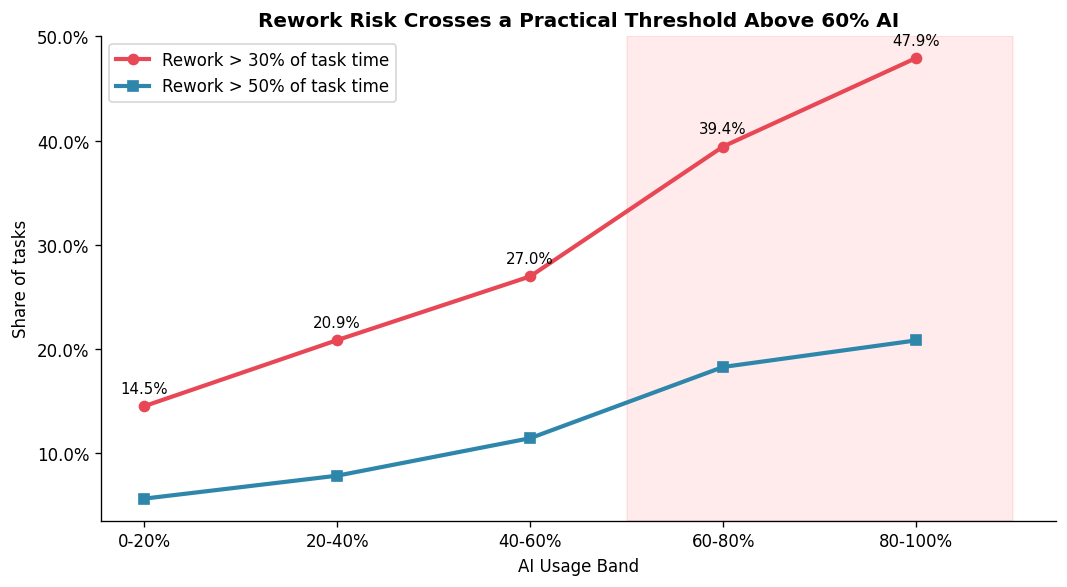

,ai_band,n,avg_rework,pct_rework_above_30,pct_rework_above_50,avg_outcome
0,0-20%,778,0.191,0.145,0.057,69.018
1,20-40%,1069,0.218,0.209,0.079,68.734
2,40-60%,812,0.260,0.270,0.115,69.484
3,60-80%,350,0.322,0.394,0.183,68.123
4,80-100%,48,0.362,0.479,0.208,64.388


In [9]:
# Quantify the operational threshold where rework becomes a serious risk
rework_thresholds = (
    data_clean.groupby("ai_band", observed=False)
    .agg(
        n=("task_id", "count"),
        avg_rework=("rework_ratio_capped", "mean"),
        pct_rework_above_30=("rework_ratio_capped", lambda s: (s > 0.30).mean()),
        pct_rework_above_50=("rework_ratio_capped", lambda s: (s > 0.50).mean()),
        avg_outcome=("outcome_score", "mean"),
    )
    .reset_index()
)
rework_thresholds.to_csv(RESULTS_DIR / "rework_thresholds.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rework_thresholds["ai_band"].astype(str), rework_thresholds["pct_rework_above_30"] * 100,
        marker="o", linewidth=2.5, color="#E84855", label="Rework > 30% of task time")
ax.plot(rework_thresholds["ai_band"].astype(str), rework_thresholds["pct_rework_above_50"] * 100,
        marker="s", linewidth=2.5, color="#2E86AB", label="Rework > 50% of task time")
ax.axvspan(2.5, 4.5, alpha=0.08, color="red")
ax.set_title("Rework Risk Crosses a Practical Threshold Above 60% AI", fontweight="bold")
ax.set_xlabel("AI Usage Band")
ax.set_ylabel("Share of tasks")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
for i, v in enumerate(rework_thresholds["pct_rework_above_30"] * 100):
    ax.annotate(f"{v:.1f}%", (i, v), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)
plt.tight_layout()
fig.savefig(IMAGES_DIR / "rework_thresholds.png", bbox_inches="tight")
plt.show()

display(rework_thresholds.round(3))


## Generate the Pricing Model Figure

This is the key experiment. The aggregate trend hides opposite dynamics, so this cell splits the data by pricing model and AI usage band. The output figure and table should show why hourly pricing is risky: fewer hours can mean less billable revenue, while fixed and value-based pricing can keep revenue stable and convert saved time into margin.


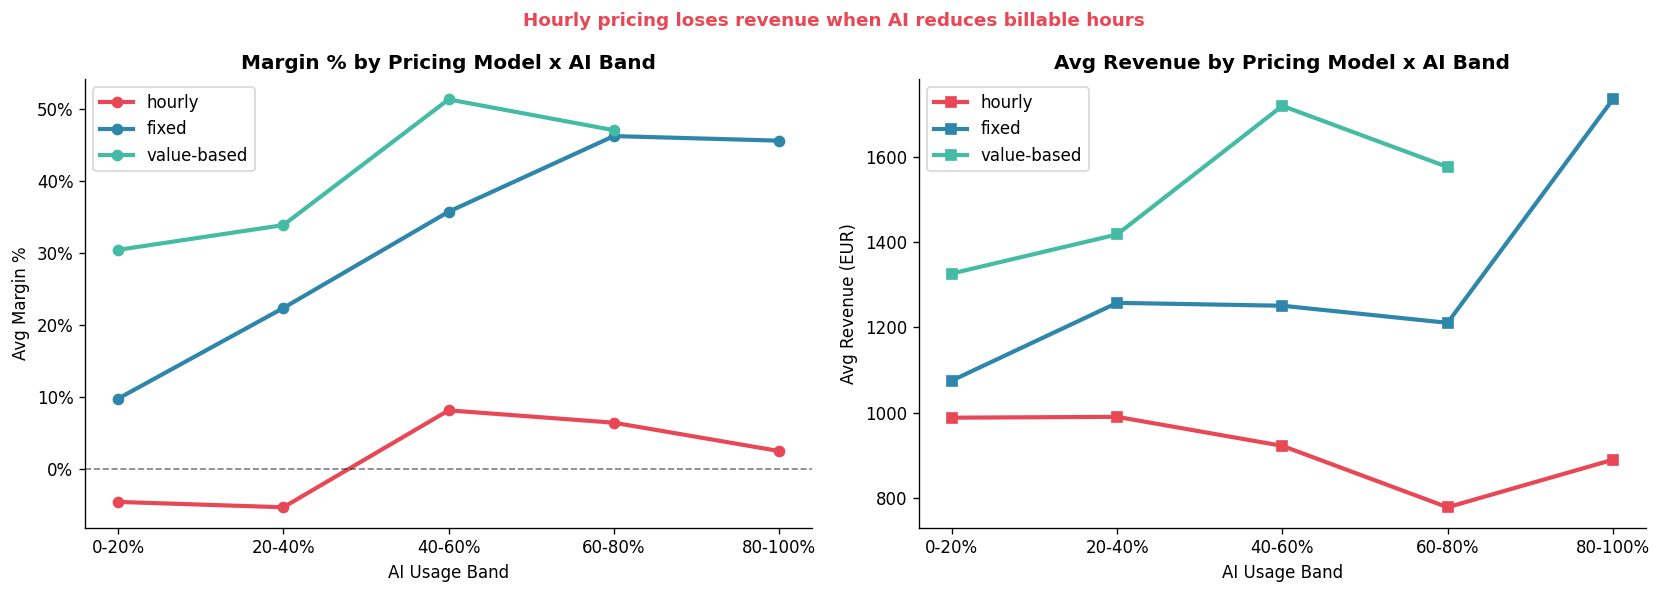

,pricing_model,ai_band,n,avg_hours,avg_revenue,avg_margin
0,fixed,0-20%,303,13.131,1075.212,0.098
1,fixed,20-40%,401,13.485,1257.658,0.224
2,fixed,40-60%,296,12.466,1250.897,0.357
3,fixed,60-80%,134,11.114,1210.812,0.462
4,fixed,80-100%,19,10.578,1735.536,0.456
5,hourly,0-20%,365,13.713,987.943,-0.046
6,hourly,20-40%,526,13.695,989.962,-0.053
7,hourly,40-60%,395,13.028,921.818,0.081
8,hourly,60-80%,174,10.354,777.565,0.064
9,hourly,80-100%,22,11.541,889.131,0.025


In [10]:
#Split data by pricing model and AI band to reveal the hidden pattern
pricing_summary = (
    data_clean.groupby(["pricing_model", "ai_band"], observed=False)
    .agg(
        n           = ("task_id",     "count"),
        avg_hours   = ("hours_spent", "mean"),
        avg_revenue = ("revenue",     "mean"),
        avg_margin  = ("margin_pct",  "mean"),
    )
    .reset_index()
)

pricing_summary["ai_band"] = pd.Categorical(pricing_summary["ai_band"], categories=ORDER, ordered=True)
pricing_summary = pricing_summary[pricing_summary["n"] >= 10].sort_values(["pricing_model", "ai_band"])
pricing_summary.to_csv(RESULTS_DIR / "pricing_model_summary.csv", index=False)

models = ["hourly", "fixed", "value_based"]
colors = {"hourly": "#E84855", "fixed": "#2E86AB", "value_based": "#44BBA4"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Left chart: margin by pricing model
ax = axes[0]
for model in models:
    subset = pricing_summary[pricing_summary["pricing_model"] == model]
    ax.plot(subset["ai_band"].astype(str), subset["avg_margin"] * 100,
            marker="o", linewidth=2.5, label=model.replace("_", "-"),
            color=colors[model])
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_title("Margin % by Pricing Model x AI Band", fontweight="bold")
ax.set_xlabel("AI Usage Band")
ax.set_ylabel("Avg Margin %")
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

#Right chart: revenue by pricing model
ax = axes[1]
for model in models:
    subset = pricing_summary[pricing_summary["pricing_model"] == model]
    ax.plot(subset["ai_band"].astype(str), subset["avg_revenue"],
            marker="s", linewidth=2.5, label=model.replace("_", "-"),
            color=colors[model])
ax.set_title("Avg Revenue by Pricing Model x AI Band", fontweight="bold")
ax.set_xlabel("AI Usage Band")
ax.set_ylabel("Avg Revenue (EUR)")
ax.legend()

plt.suptitle("Hourly pricing loses revenue when AI reduces billable hours",
             fontsize=11, fontweight="bold", color="#E84855")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "pricing_model_mechanism.png", bbox_inches="tight")
plt.show()

display(pricing_summary.round(3))


### Controlled Model: Is AI Still Associated With Speed and Margin?

The previous charts compare groups directly. This cell adds a simple controlled linear model using only `numpy` and `pandas`, so the project remains easy to reproduce. The model controls for pricing model, task type, seniority, task complexity, brief quality, and rework. The result should be read as an association, not a causal proof.


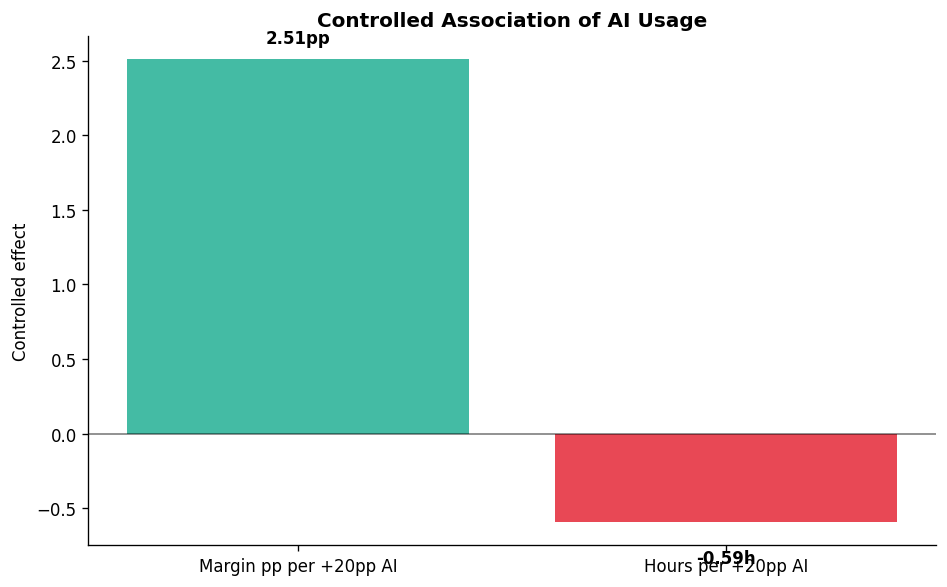

,model,r2,ai_coef_per_100pp,ai_effect_per_20pp,rework_coef
0,Capped margin %,0.174,0.126,0.025,0.137
1,Hours spent,0.173,-2.975,-0.595,-9.470


In [11]:
# Simple OLS using numpy, kept dependency-free for reproducibility
model_df = data_clean[[
    "margin_pct_capped", "hours_spent", "ai_usage_pct", "rework_ratio_capped",
    "task_complexity_score", "brief_quality_score", "pricing_model", "seniority", "task_type"
]].dropna().copy()

X = pd.get_dummies(
    model_df[[
        "ai_usage_pct", "rework_ratio_capped", "task_complexity_score", "brief_quality_score",
        "pricing_model", "seniority", "task_type"
    ]],
    drop_first=True,
    dtype=float,
)
X.insert(0, "intercept", 1.0)

def fit_ols(y_col):
    y = model_df[y_col].to_numpy(dtype=float)
    X_values = X.to_numpy(dtype=float)
    beta = np.linalg.lstsq(X_values, y, rcond=None)[0]
    pred = X_values @ beta
    r2 = 1 - ((y - pred) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return pd.Series(beta, index=X.columns), r2

margin_beta, margin_r2 = fit_ols("margin_pct_capped")
hours_beta, hours_r2 = fit_ols("hours_spent")

controlled_summary = pd.DataFrame([
    {
        "model": "Capped margin %",
        "r2": margin_r2,
        "ai_coef_per_100pp": margin_beta["ai_usage_pct"],
        "ai_effect_per_20pp": margin_beta["ai_usage_pct"] * 0.20,
        "rework_coef": margin_beta["rework_ratio_capped"],
    },
    {
        "model": "Hours spent",
        "r2": hours_r2,
        "ai_coef_per_100pp": hours_beta["ai_usage_pct"],
        "ai_effect_per_20pp": hours_beta["ai_usage_pct"] * 0.20,
        "rework_coef": hours_beta["rework_ratio_capped"],
    },
])
controlled_summary.to_csv(RESULTS_DIR / "controlled_model_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = controlled_summary.copy()
plot_df["display_effect"] = [plot_df.loc[0, "ai_effect_per_20pp"] * 100, plot_df.loc[1, "ai_effect_per_20pp"]]
colors_control = ["#44BBA4", "#E84855"]
bars = ax.bar(["Margin pp per +20pp AI", "Hours per +20pp AI"], plot_df["display_effect"], color=colors_control)
ax.axhline(0, color="black", linewidth=1, alpha=0.5)
ax.set_title("Controlled Association of AI Usage", fontweight="bold")
ax.set_ylabel("Controlled effect")
for b, v in zip(bars, plot_df["display_effect"]):
    suffix = "pp" if b.get_x() < 0.5 else "h"
    ax.text(b.get_x() + b.get_width()/2, v + (0.08 if v >= 0 else -0.18),
            f"{v:.2f}{suffix}", ha="center", va="bottom" if v >= 0 else "top", fontweight="bold")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "controlled_ai_effects.png", bbox_inches="tight")
plt.show()

display(controlled_summary.round(3))


## Generate Seniority and Task-Type Figures

This cell creates two exploratory figures: a seniority chart comparing AI’s effects across junior, mid-level, and senior workers, and a task-type heatmap showing where AI appears to add value or introduce quality risks.

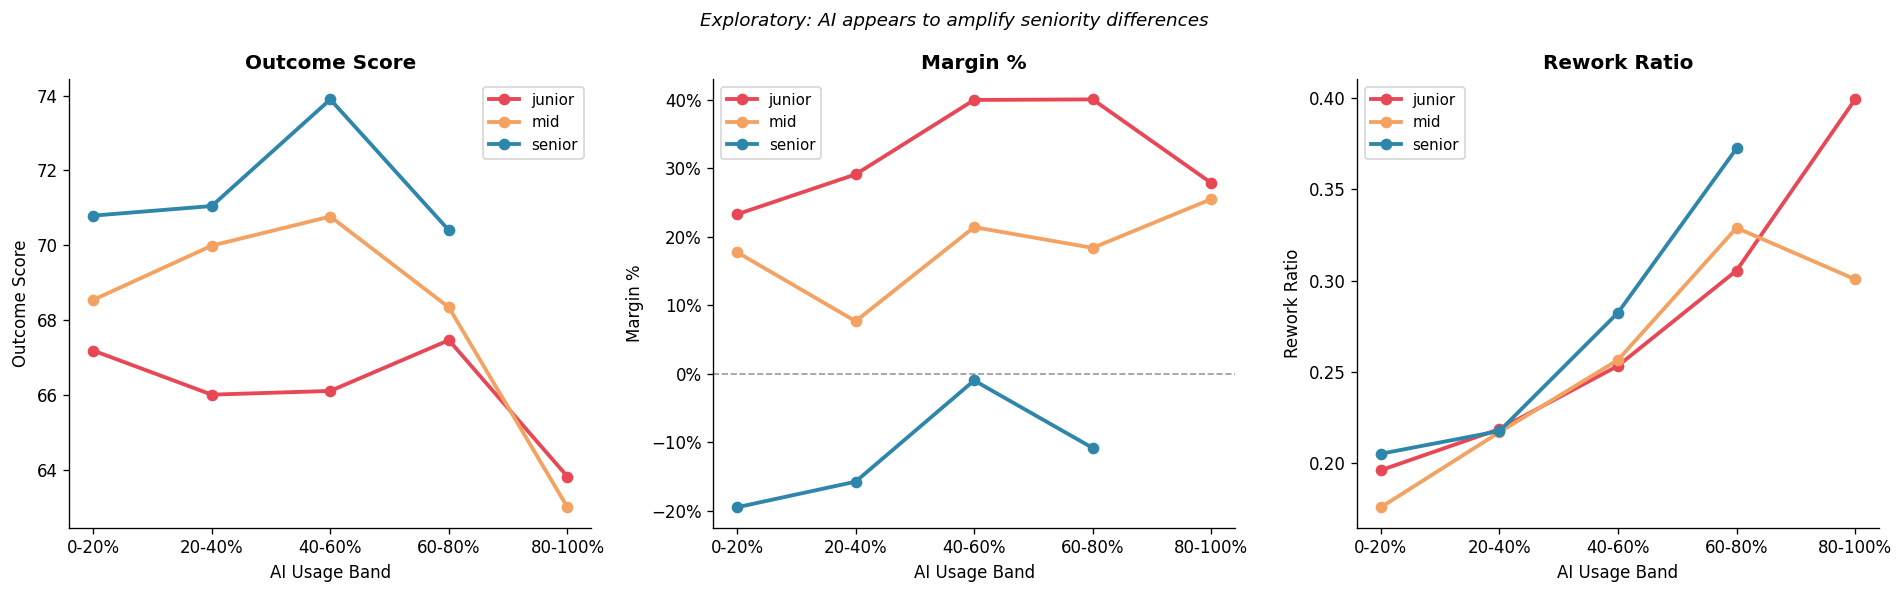

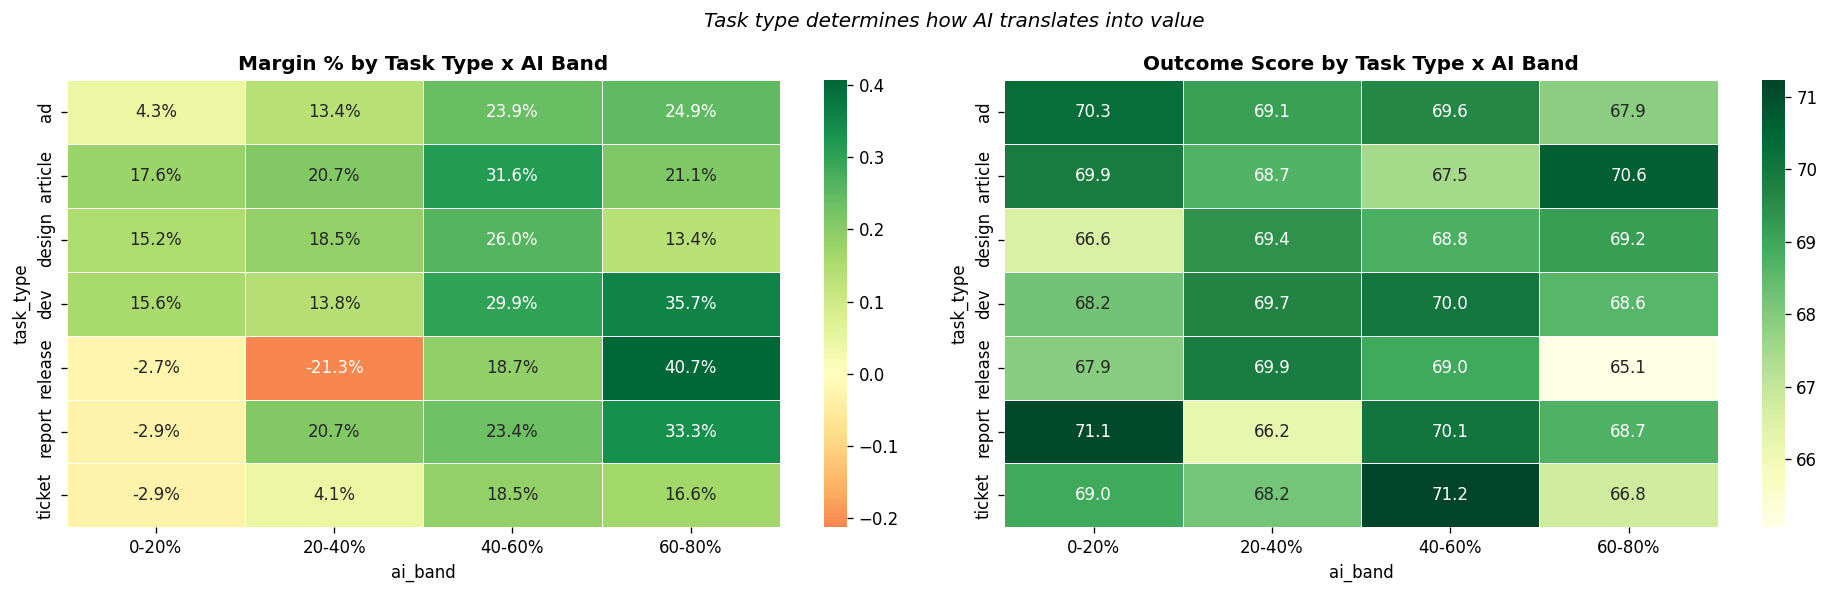

In [12]:
#Compare how AI affects junior, mid, and senior workers differently
sen = (
    data_clean.groupby(["seniority", "ai_band"], observed=False)
    .agg(
        n           = ("task_id",             "count"),
        avg_outcome = ("outcome_score",        "mean"),
        avg_margin  = ("margin_pct",           "mean"),
        avg_rework  = ("rework_ratio_capped",  "mean"),
    )
    .reset_index()
)
sen["ai_band"] = pd.Categorical(sen["ai_band"], categories=ORDER, ordered=True)
sen = sen[sen["n"] >= 10].sort_values(["seniority", "ai_band"])
sen.to_csv(RESULTS_DIR / "seniority_summary.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
seniority_order = ["junior", "mid", "senior"]
colors_sen = {"junior": "#E84855", "mid": "#F4A261", "senior": "#2E86AB"}

for ax, metric, ylabel in zip(
    axes,
    ["avg_outcome", "avg_margin", "avg_rework"],
    ["Outcome Score", "Margin %", "Rework Ratio"],
):
    for seniority in seniority_order:
        subset = sen[sen["seniority"] == seniority]
        vals = subset[metric] * (100 if metric == "avg_margin" else 1)
        ax.plot(subset["ai_band"].astype(str), vals,
                marker="o", linewidth=2.3, label=seniority,
                color=colors_sen[seniority])
    ax.set_title(ylabel, fontweight="bold")
    ax.set_xlabel("AI Usage Band")
    ax.set_ylabel(ylabel)
    if metric == "avg_margin":
        ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.4)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=9)

plt.suptitle("Exploratory: AI appears to amplify seniority differences",
             fontsize=11, style="italic")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "seniority_patterns.png", bbox_inches="tight")
plt.show()

#Show margin and outcome score as heatmaps by task type and AI band
task_sum = (
    data_clean.groupby(["task_type", "ai_band"], observed=False)
    .agg(
        n           = ("task_id",       "count"),
        avg_margin  = ("margin_pct",    "mean"),
        avg_outcome = ("outcome_score", "mean"),
    )
    .reset_index()
)
task_sum["ai_band"] = pd.Categorical(task_sum["ai_band"], categories=ORDER, ordered=True)
task_sum = task_sum[task_sum["n"] >= 20].sort_values(["task_type", "ai_band"])
task_sum.to_csv(RESULTS_DIR / "task_type_summary.csv", index=False)

pivot_margin  = task_sum.pivot(index="task_type", columns="ai_band", values="avg_margin")
pivot_outcome = task_sum.pivot(index="task_type", columns="ai_band", values="avg_outcome")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pivot_margin, annot=True, fmt=".1%", cmap="RdYlGn",
            ax=axes[0], linewidths=0.5, center=0)
axes[0].set_title("Margin % by Task Type x AI Band", fontweight="bold")

sns.heatmap(pivot_outcome, annot=True, fmt=".1f", cmap="YlGn",
            ax=axes[1], linewidths=0.5)
axes[1].set_title("Outcome Score by Task Type x AI Band", fontweight="bold")

plt.suptitle("Task type determines how AI translates into value",
             fontsize=12, style="italic")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "task_type_heatmap.png", bbox_inches="tight")
plt.show()


## Generate the Loss-Rate Figure

This cell checks whether higher AI usage reduces loss-making tasks. The first panel shows the aggregate loss rate. The second panel splits loss rate by pricing model, which is necessary because the aggregate pattern can be misleading if higher-AI bands contain more fixed and value-based contracts.


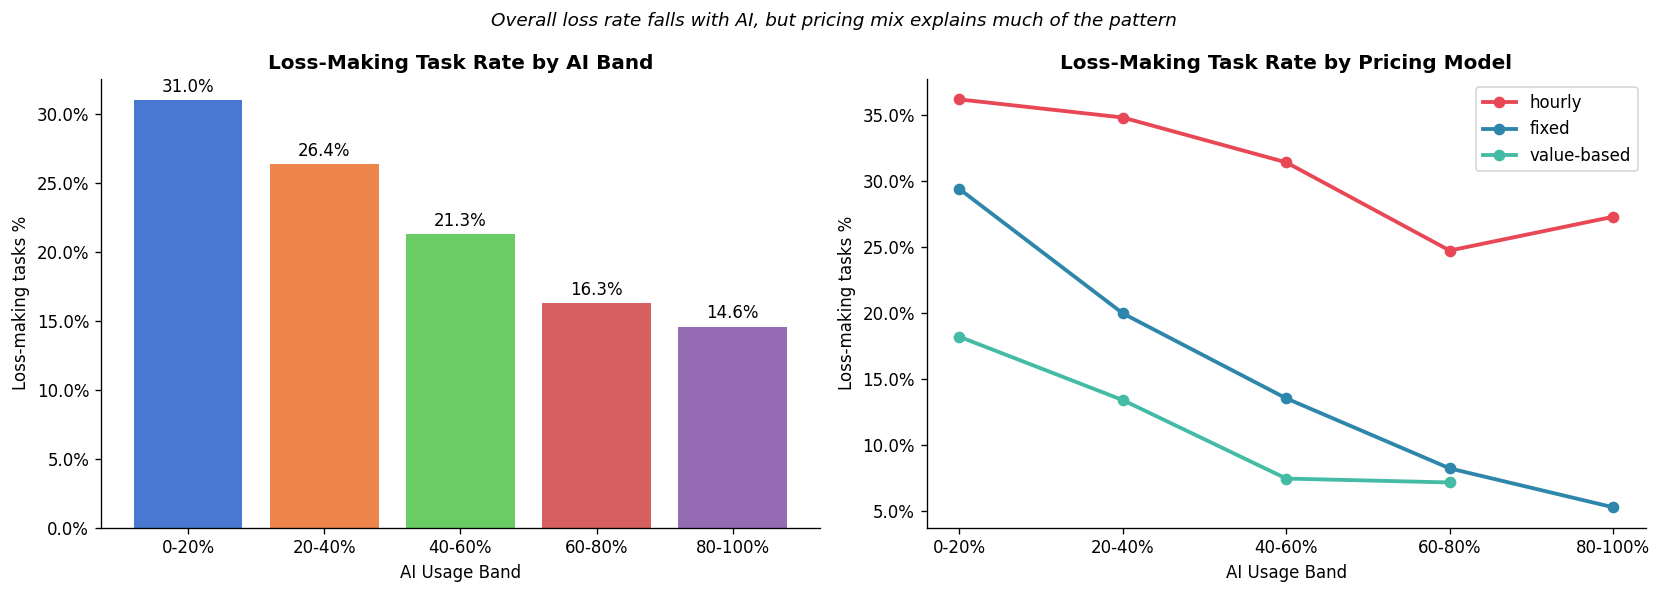

In [13]:
#Check whether higher AI usage reduces the share of loss-making tasks
loss = (
    data_clean.groupby("ai_band", observed=False)
    .agg(n=("task_id", "count"), loss_rate=("is_loss", "mean"))
    .reset_index()
)
loss["ai_band"] = pd.Categorical(loss["ai_band"], categories=ORDER, ordered=True)
loss = loss.sort_values("ai_band").reset_index(drop=True)
loss.to_csv(RESULTS_DIR / "loss_rate_summary.csv", index=False)

#Same calculation split by pricing model
loss_pm = (
    data_clean.groupby(["pricing_model", "ai_band"], observed=False)
    .agg(n=("task_id", "count"), loss_rate=("is_loss", "mean"))
    .reset_index()
)
loss_pm["ai_band"] = pd.Categorical(loss_pm["ai_band"], categories=ORDER, ordered=True)
loss_pm = loss_pm[loss_pm["n"] >= 10].sort_values(["pricing_model", "ai_band"])
loss_pm.to_csv(RESULTS_DIR / "loss_rate_by_pricing.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Left chart: overall loss rate
ax = axes[0]
bars = ax.bar(loss["ai_band"].astype(str), loss["loss_rate"] * 100,
              color=sns.color_palette("muted", 5))
ax.set_title("Loss-Making Task Rate by AI Band", fontweight="bold")
ax.set_xlabel("AI Usage Band")
ax.set_ylabel("Loss-making tasks %")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for b, v in zip(bars, loss["loss_rate"] * 100):
    ax.text(b.get_x() + b.get_width()/2, v + 0.3, f"{v:.1f}%",
            ha="center", va="bottom", fontsize=10)

#Right chart: loss rate by pricing model
ax = axes[1]
for model in models:
    subset = loss_pm[loss_pm["pricing_model"] == model]
    ax.plot(subset["ai_band"].astype(str), subset["loss_rate"] * 100,
            marker="o", linewidth=2.3, label=model.replace("_", "-"),
            color=colors[model])
ax.set_title("Loss-Making Task Rate by Pricing Model", fontweight="bold")
ax.set_xlabel("AI Usage Band")
ax.set_ylabel("Loss-making tasks %")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()

plt.suptitle("Overall loss rate falls with AI, but pricing mix explains much of the pattern",
             fontsize=11, style="italic")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "loss_rate_mix_effect.png", bbox_inches="tight")
plt.show()


### Pricing-Mix Decomposition

The loss-rate chart shows that losses fall at higher AI usage. This cell separates two explanations: the pricing-model composition of each AI band and the loss rate inside each pricing model. It tests whether the aggregate improvement is only a mix effect or whether within-model performance also changes.


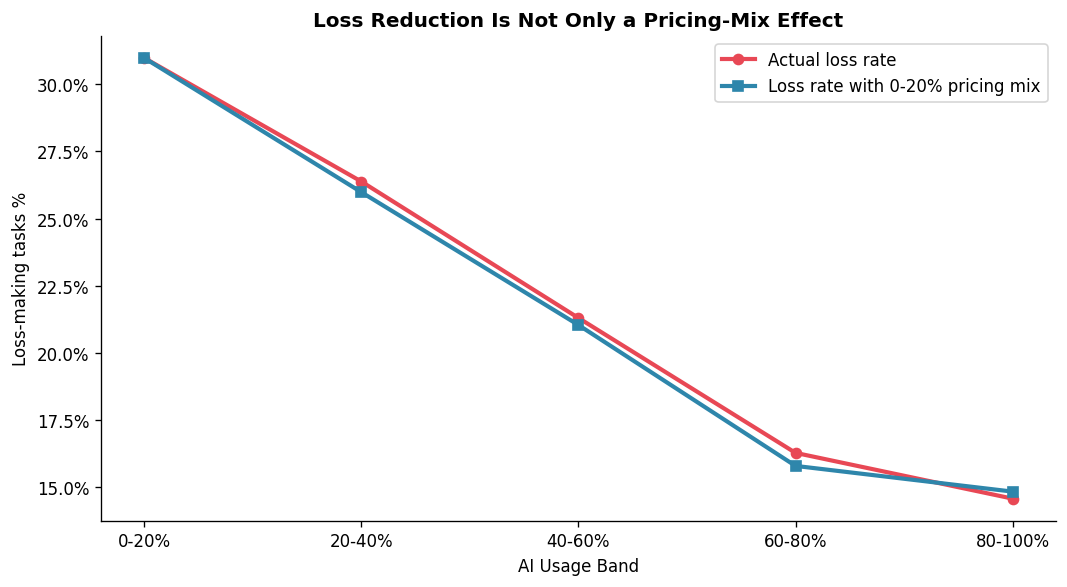

pricing_model,fixed,hourly,value_based
ai_band,,,
0-20%,0.389,0.469,0.141
20-40%,0.375,0.492,0.133
40-60%,0.365,0.486,0.149
60-80%,0.383,0.497,0.120
80-100%,0.396,0.458,0.146


,ai_band,actual_loss_rate,loss_rate_using_0_20_pricing_mix,pricing_mix_gap
0,0-20%,0.310,0.310,0.000
1,20-40%,0.264,0.260,0.004
2,40-60%,0.213,0.210,0.003
3,60-80%,0.163,0.158,0.005
4,80-100%,0.146,0.148,-0.003


In [14]:
# Separate pricing composition from within-pricing loss rates
pricing_counts = (
    data_clean.groupby(["ai_band", "pricing_model"], observed=False)
    .size()
    .rename("n")
    .reset_index()
)
pricing_counts["share"] = pricing_counts["n"] / pricing_counts.groupby("ai_band", observed=False)["n"].transform("sum")
pricing_mix = pricing_counts[["ai_band", "pricing_model", "share"]]
pricing_mix.to_csv(RESULTS_DIR / "pricing_mix_shares.csv", index=False)

base_mix = data_clean[data_clean["ai_band"] == "0-20%"].groupby("pricing_model").size()
base_mix = base_mix / base_mix.sum()

loss_mix_rows = []
for band in ORDER:
    subset = loss_pm[loss_pm["ai_band"] == band]
    loss_with_base_mix = sum(
        base_mix.get(row["pricing_model"], 0) * row["loss_rate"]
        for _, row in subset.iterrows()
    )
    actual_loss = data_clean.loc[data_clean["ai_band"] == band, "is_loss"].mean()
    loss_mix_rows.append({
        "ai_band": band,
        "actual_loss_rate": actual_loss,
        "loss_rate_using_0_20_pricing_mix": loss_with_base_mix,
        "pricing_mix_gap": actual_loss - loss_with_base_mix,
    })

loss_mix = pd.DataFrame(loss_mix_rows)
loss_mix.to_csv(RESULTS_DIR / "loss_mix_decomposition.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(loss_mix["ai_band"], loss_mix["actual_loss_rate"] * 100, marker="o", linewidth=2.5,
        color="#E84855", label="Actual loss rate")
ax.plot(loss_mix["ai_band"], loss_mix["loss_rate_using_0_20_pricing_mix"] * 100, marker="s", linewidth=2.5,
        color="#2E86AB", label="Loss rate with 0-20% pricing mix")
ax.set_title("Loss Reduction Is Not Only a Pricing-Mix Effect", fontweight="bold")
ax.set_xlabel("AI Usage Band")
ax.set_ylabel("Loss-making tasks %")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
fig.savefig(IMAGES_DIR / "loss_mix_decomposition.png", bbox_inches="tight")
plt.show()

display(pricing_mix.pivot(index="ai_band", columns="pricing_model", values="share").round(3))
display(loss_mix.round(3))


## Create the README Workflow Figure and Manifest

Creates the workflow figure, saves it to the `images` folder, and writes a small manifest listing the files generated by the notebook.

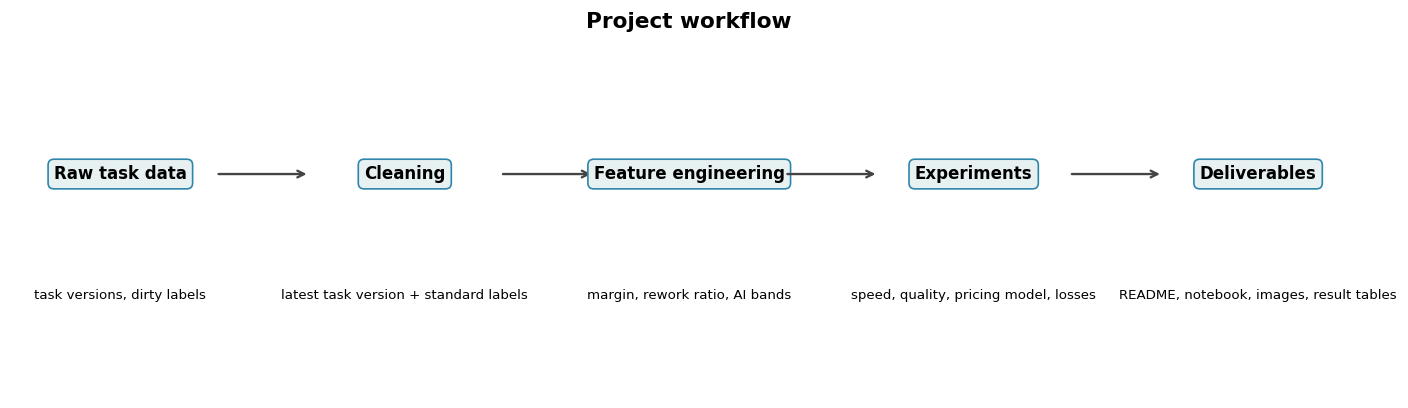

Generated project assets:
- images/project_workflow.png
- images/ai_band_overview.png
- images/quality_tradeoff.png
- images/pricing_model_mechanism.png
- images/seniority_patterns.png
- images/task_type_heatmap.png
- images/loss_rate_mix_effect.png
- images/rework_thresholds.png
- images/controlled_ai_effects.png
- images/loss_mix_decomposition.png
- results/ai_band_summary.csv
- results/pricing_model_summary.csv
- results/loss_rate_summary.csv
- results/loss_rate_by_pricing.csv
- results/seniority_summary.csv
- results/task_type_summary.csv
- results/robustness_summary.csv
- results/rework_thresholds.csv
- results/controlled_model_summary.csv
- results/pricing_mix_shares.csv
- results/loss_mix_decomposition.csv


In [15]:
#Generate a workflow figure for README.md and list produced assets
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.axis("off")

steps = [
    ("Raw task data", "task versions, dirty labels"),
    ("Cleaning", "latest task version + standard labels"),
    ("Feature engineering", "margin, rework ratio, AI bands"),
    ("Experiments", "speed, quality, pricing model, losses"),
    ("Deliverables", "README, notebook, images, result tables"),
]

x_positions = np.linspace(0.08, 0.92, len(steps))
for i, ((title, subtitle), x_pos) in enumerate(zip(steps, x_positions)):
    ax.text(
        x_pos, 0.62, title,
        ha="center", va="center", fontsize=10, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#E8F1F2", edgecolor="#2E86AB"),
    )
    ax.text(x_pos, 0.28, subtitle, ha="center", va="center", fontsize=8, wrap=True)
    if i < len(steps) - 1:
        ax.annotate(
            "", xy=(x_positions[i + 1] - 0.07, 0.62), xytext=(x_pos + 0.07, 0.62),
            arrowprops=dict(arrowstyle="->", lw=1.4, color="#444444"),
        )

plt.title("Project workflow", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "project_workflow.png", bbox_inches="tight")
plt.show()

manifest = [
    "Generated project assets:",
    "- images/project_workflow.png",
    "- images/ai_band_overview.png",
    "- images/quality_tradeoff.png",
    "- images/pricing_model_mechanism.png",
    "- images/seniority_patterns.png",
    "- images/task_type_heatmap.png",
    "- images/loss_rate_mix_effect.png",
    "- images/rework_thresholds.png",
    "- images/controlled_ai_effects.png",
    "- images/loss_mix_decomposition.png",
    "- results/ai_band_summary.csv",
    "- results/pricing_model_summary.csv",
    "- results/loss_rate_summary.csv",
    "- results/loss_rate_by_pricing.csv",
    "- results/seniority_summary.csv",
    "- results/task_type_summary.csv",
    "- results/robustness_summary.csv",
    "- results/rework_thresholds.csv",
    "- results/controlled_model_summary.csv",
    "- results/pricing_mix_shares.csv",
    "- results/loss_mix_decomposition.csv",
]
(RESULTS_DIR / "manifest.txt").write_text("\n".join(manifest), encoding="utf-8")
print("\n".join(manifest))
